### Lab Assignment 5 (Artificial Neural Network)

### Group No. - 9<br>
* Rohit Kumar - 24EE10083<br>
* Rishabh Sethia - 24EE10082<br>
* Rathalavth Vishal - 24EE10081<br>

In [199]:
# Importing the required libraries alltogether 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy

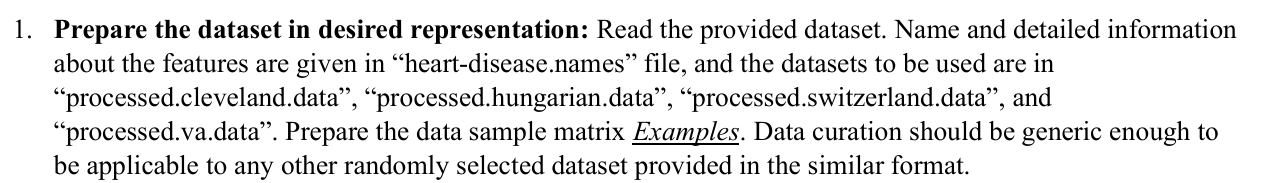

In [200]:
# cols stores the name of the attributes that we will be using 
cols=["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]
# loading the data 
clv_df=pd.read_csv("processed.cleveland.data",header=None,names=cols)
hung_df=pd.read_csv("processed.hungarian.data",header=None,names=cols)
switz_df=pd.read_csv("processed.switzerland.data",header=None,names=cols)
va_df=pd.read_csv("processed.va.data",header=None,names=cols)

In [201]:
clv_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [202]:
hung_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0


In [203]:
switz_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,32,1,1,95,0,?,0,127,0,.7,1,?,?,1
1,34,1,4,115,0,?,?,154,0,.2,1,?,?,1
2,35,1,4,?,0,?,0,130,1,?,?,?,7,3
3,36,1,4,110,0,?,0,125,1,1,2,?,6,1
4,38,0,4,105,0,?,0,166,0,2.8,1,?,?,2


In [204]:
va_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,4,140,260,0,1,112,1,3,2,?,?,2
1,44,1,4,130,209,0,1,127,0,0,?,?,?,0
2,60,1,4,132,218,0,1,140,1,1.5,3,?,?,2
3,55,1,4,142,228,0,1,149,1,2.5,1,?,?,1
4,66,1,3,110,213,1,2,99,1,1.3,2,?,?,0


In [205]:
# combining the loaded datasets into a single one for later use
df=pd.concat([clv_df,hung_df,switz_df,va_df]).reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   sex       920 non-null    float64
 2   cp        920 non-null    float64
 3   trestbps  920 non-null    object 
 4   chol      920 non-null    object 
 5   fbs       920 non-null    object 
 6   restecg   920 non-null    object 
 7   thalach   920 non-null    object 
 8   exang     920 non-null    object 
 9   oldpeak   920 non-null    object 
 10  slope     920 non-null    object 
 11  ca        920 non-null    object 
 12  thal      920 non-null    object 
 13  num       920 non-null    int64  
dtypes: float64(3), int64(1), object(10)
memory usage: 100.8+ KB


In [206]:
# handling the missing values
clv_df.replace(['?'], np.nan, inplace=True)
hung_df.replace(['?'], np.nan, inplace=True)
switz_df.replace(['?'], np.nan, inplace=True)
va_df.replace(['?'], np.nan, inplace=True)

In [207]:
clv_df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

In [208]:
clv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    object 
 12  thal      301 non-null    object 
 13  num       303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [209]:
# dropping the instances which had missing values in them 
clv_pcsd=clv_df.dropna()
hung_pcsd=hung_df.dropna()
switz_pcsd=switz_df.dropna()
va_pcsd=va_df.dropna()

In [210]:
clv_pcsd.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [211]:
hung_pcsd.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [212]:
switz_pcsd.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [213]:
va_pcsd.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [214]:
# declaring the dataframe for the XOR gate implementation using ANN
xor_data=pd.DataFrame([[0,0,0],
                       [0,1,1],
                       [1,0,1],
                       [1,1,0]],columns=["x1","x2","y"])
xor_data

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


In [215]:
# declaring the XNOR dataframe for the XNOR gagte implementation using ANN
xnor_data=xor_data.copy()
xnor_data["y"]=1-xor_data["y"].copy()
xnor_data

,x1,x2,y
0,0,0,1
1,0,1,0
2,1,0,0
3,1,1,1


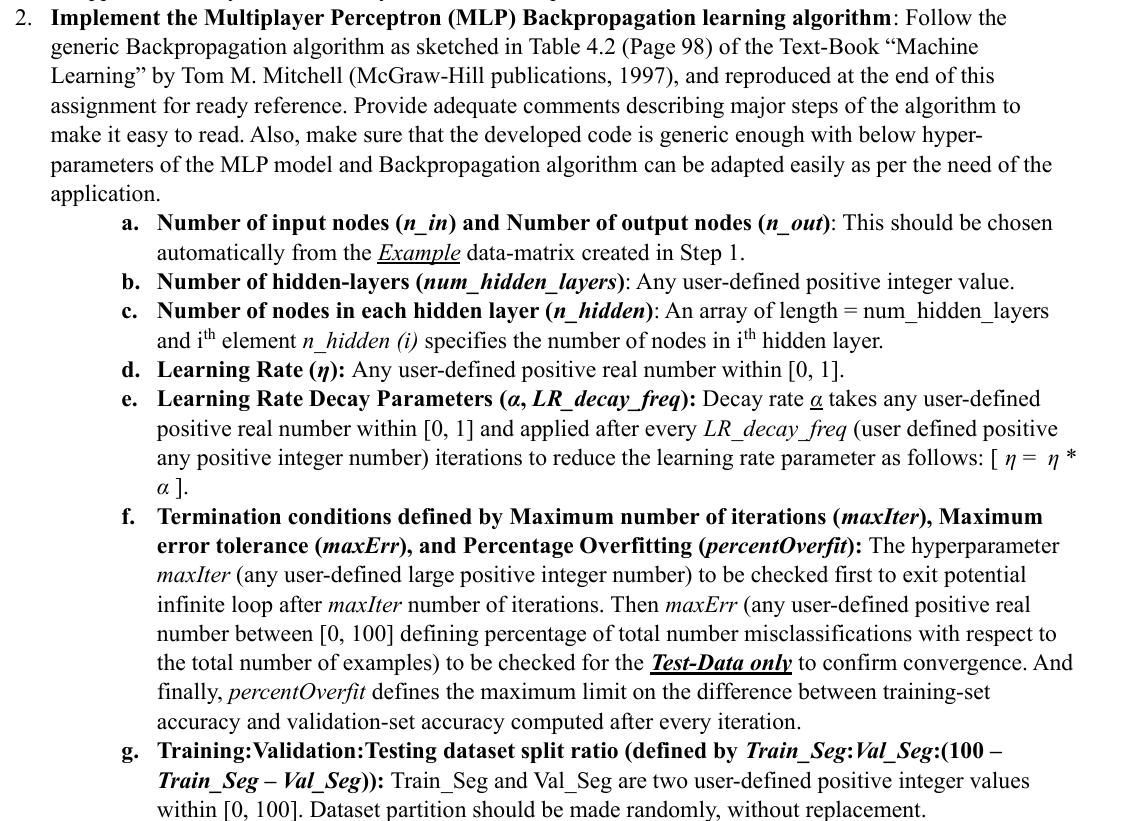

In [237]:
# Implementation of a Multilayer Perceptron using Backpropagation
class MLP:

    # Constructor: initializes all network hyperparameters and storage variables
    def __init__(self,Examples,num_hidden_layers=1,n_hidden=[2],lr=0.01,
                 random_init=True,initial_val=0,alpha=1,lr_decay_freq=np.inf,
                 maxIter=1000,maxErr=0,percentOverfit=100,
                 train_seg=70,val_seg=10,confusion_flag=False):

        # Dataset
        self.Examples = Examples

        # Network architecture
        self.num_hidden_layers = num_hidden_layers
        self.n_hidden = n_hidden

        # Learning parameters
        self.lr = lr                      # learning rate
        self.alpha = alpha                # decay factor
        self.lr_decay_freq = lr_decay_freq

        # Stopping conditions
        self.maxIter = maxIter
        self.maxErr = maxErr
        self.percentOverfit = percentOverfit

        # Dataset split percentages
        self.train_seg = train_seg
        self.val_seg = val_seg

        # Input dimension
        self.n_in = Examples.shape[1] - 1

        # Output dimension (binary ->1 neuron, multi-class -> number of classes)
        tmp = Examples.iloc[:,-1].nunique()
        self.n_out = tmp if tmp!=2 else 1

        # Storage variables
        self.weights = []
        self.train_error_hist = []
        self.val_error_hist = []
        self.test_error_hist = []
        self.w_hist = []

        # Weight initialization settings
        self.random_init = random_init
        self.initial_val = float(initial_val)

        # Iteration counter
        self.itr = 1

        # Flag to print confusion matrix
        self.conf_flag = confusion_flag


    # Initialize weights with a constant value
    def initialise_weights(self,initial_val):

        if(self.num_hidden_layers>0):

            # weights between input and first hidden layer
            wt=[np.full((self.n_in+1,self.n_hidden[0]),initial_val)]

            # weights between hidden layers
            for i in range(self.num_hidden_layers-1):
                wt.append(np.full((self.n_hidden[i]+1,self.n_hidden[i+1]),initial_val))

            # weights between last hidden and output layer
            wt.append(np.full((self.n_hidden[-1]+1,self.n_out),initial_val))

        else:
            # direct input to output connection
            wt=[np.full((self.n_in+1,self.n_out),initial_val)]

        self.weights = wt


    # Random weight initialization using Gaussian distribution
    def initialise_weights_random(self):

        if(self.num_hidden_layers>0):

            wt=[0.1*np.random.randn(self.n_in+1,self.n_hidden[0])]

            for i in range(self.num_hidden_layers-1):
                wt.append(0.1*np.random.randn(self.n_hidden[i]+1,self.n_hidden[i+1]))

            wt.append(0.1*np.random.randn(self.n_hidden[-1]+1,self.n_out))

        else:
            wt=[0.1*np.random.randn(self.n_in+1,self.n_out)]

        self.weights = wt


    # Sigmoid activation function
    def sigmoid(self,z):
        return 1/(1+np.exp(-z))


    # Forward propagation through the network
    def forward_prop(self,x0):

        # list storing inputs (including bias)
        x=[np.append(1,x0)]

        # list storing outputs of each layer
        o=[]

        # propagate through hidden layers
        for i in range(self.num_hidden_layers):

            o.append(self.sigmoid(x[i]@self.weights[i]))
            x.append(np.append(1,o[i]))

        # output layer
        o.append(self.sigmoid(x[-1]@self.weights[-1]))

        return o,x


    # Backpropagation algorithm to compute deltas (error signals)
    def backprop(self,out,target):

        delta=[[] for i in range(len(out))]

        # delta for output layer
        delta[-1]=np.array(out[-1]*(np.ones_like(out[-1])-out[-1])*(target-out[-1]))

        # deltas for hidden layers (backward recursion)
        for i in range(len(out)-2,-1,-1):
            delta[i]=np.array((out[i]*(np.ones_like(out[i])-out[i]))*
                              (self.weights[i+1][1:]@delta[i+1]))

        return delta


    # Update weights using gradient descent rule
    def weight_update(self,x,delta):

        for i in range(len(x)):
            delw = self.lr * x[i].reshape(-1,1) @ delta[i].reshape(-1,1).T
            self.weights[i] += delw


    # Randomly split dataset into train/validation/test
    def train_val_test_split(self,Examples):

        Examples=Examples.sample(frac=1).reset_index(drop=True)

        train=Examples.iloc[:int(self.train_seg*len(Examples)/100)]

        val=Examples.iloc[int(self.train_seg*len(Examples)/100):
                          int(self.train_seg*len(Examples)/100)+
                          int(self.val_seg*len(Examples)/100):]

        test=Examples.iloc[int(self.train_seg*len(Examples)/100)+
                           int(self.val_seg*len(Examples)/100):]

        return train,val,test


    # Predict output for a single sample
    def predict(self,xpred):

        output,_=self.forward_prop(np.array(xpred,dtype=float))

        if(self.n_out>1):
            return np.argmax(output[-1])
        else:
            return 1 if output[-1]>0.5 else 0


    # Create dataframe containing predicted labels
    def predicted_df(self):

        copied_df=self.Examples.copy()

        x,y=copied_df.iloc[:,:-1],copied_df.iloc[:,-1]

        ypred=[]

        for i in range(len(x)):
            ypred.append(self.predict(x.iloc[i]))

        copied_df.rename(columns={"y":"y_actual"},inplace=True)

        copied_df["y_predicted"]=ypred

        return copied_df


    # Compute classification accuracy
    def find_accuracy(self,x,y):

        if(len(x)==0):
            return 0

        correct=0

        for i in range(len(x)):

            ypred=self.predict(x.iloc[i])

            if(ypred==y.iloc[i]):
                correct+=1

        return correct*100/len(x)


    # Compute confusion matrix
    def confusion_mat(self,x,y):

        if(len(x)==0):
            return []

        tp,tn,fn,fp=0,0,0,0

        for i in range(len(x)):

            ypred=self.predict(x.iloc[i])

            if(ypred==y.iloc[i]):

                if(ypred==1):
                    tp+=1
                else:
                    tn+=1

            else:

                if(ypred==0):
                    fn+=1
                else:
                    fp+=1

        mat=np.array([[tp,fp],[fn,tn]])

        print("Confusion Matrix:-")
        print(" [TP FP] : ",mat[0])
        print(" [FN TN] : ", mat[1])


    # Compute Mean Squared Error
    def find_mse_err(self,x,y):

        s=0

        for i in range(len(x)):

            ypred,_=self.forward_prop(x.iloc[i].values.astype(float))
            s+=(ypred[-1][0]-y.iloc[i])**2

        return s


    # Plot error vs iterations
    def plot_error(self,error):

        iterations = np.arange(1, len(error) + 1)

        plt.plot(iterations, error)

        plt.xlabel("Iterations")
        plt.ylabel("Squared Error (Σ (y_actual - y_predicted)^2)")
        plt.title("Squared Error vs Iterations")

        plt.show()


    # Main training routine
    def main(self):

        np.random.seed(0)

        # reset histories
        self.train_error_hist=[]
        self.val_error_hist=[]
        self.test_error_hist=[]
        self.w_hist=[]

        # split dataset
        train,val,test=self.train_val_test_split(self.Examples)

        x_train=train.iloc[:,:-1]
        y_train=train.iloc[:,-1]

        x_val=val.iloc[:,:-1]
        y_val=val.iloc[:,-1]

        x_test=test.iloc[:,:-1]
        y_test=test.iloc[:,-1]

        self.itr=1

        # initialize weights
        if(self.random_init):
            self.initialise_weights_random()
        else:
            self.initialise_weights(self.initial_val)

        flag=0

        print(f"Training the Multi-Layer Perceptron:-")

        while True:

            if(flag):
                break

            for i in range(len(x_train.values)):

                # record errors
                self.train_error_hist.append(self.find_mse_err(x_train,y_train))
                self.val_error_hist.append(self.find_mse_err(x_val,y_val))
                self.test_error_hist.append(self.find_mse_err(x_test,y_test))

                # store weights
                self.w_hist.append(deepcopy(self.weights))

                # learning rate decay
                if(self.itr%self.lr_decay_freq==0):
                    self.lr=self.lr*self.alpha

                # forward pass
                out,x_mat=self.forward_prop(x_train.iloc[i].values.astype(float))

                # backpropagation
                delta=self.backprop(out,y_train.iloc[i])

                # weight update
                self.weight_update(x_mat,delta)

                # evaluate performance
                accuracy_train=self.find_accuracy(x_train,y_train)
                accuracy_val=self.find_accuracy(x_val,y_val)

                error_test=100-self.find_accuracy(x_test,y_test)

                per_overfit=np.abs(accuracy_train-accuracy_val)

                print(f"Iteration {self.itr}....\t Training Accuracy={accuracy_train} \t Validation Accuracy={accuracy_val}",end='\r')

                # optional confusion matrix
                if(self.itr%20==0 and self.conf_flag):
                    self.confusion_mat(x_test,y_test)

                # stopping conditions
                overfit_condition = (per_overfit >= self.percentOverfit) if len(x_val) > 0 else False
                error_condition = (error_test <= self.maxErr) if len(x_test) > 0 else False

                if(self.itr>=self.maxIter or error_condition or overfit_condition):

                    flag=1
                    print(f"\nTraining ends at iteration no. {self.itr}")
                    break

                self.itr+=1

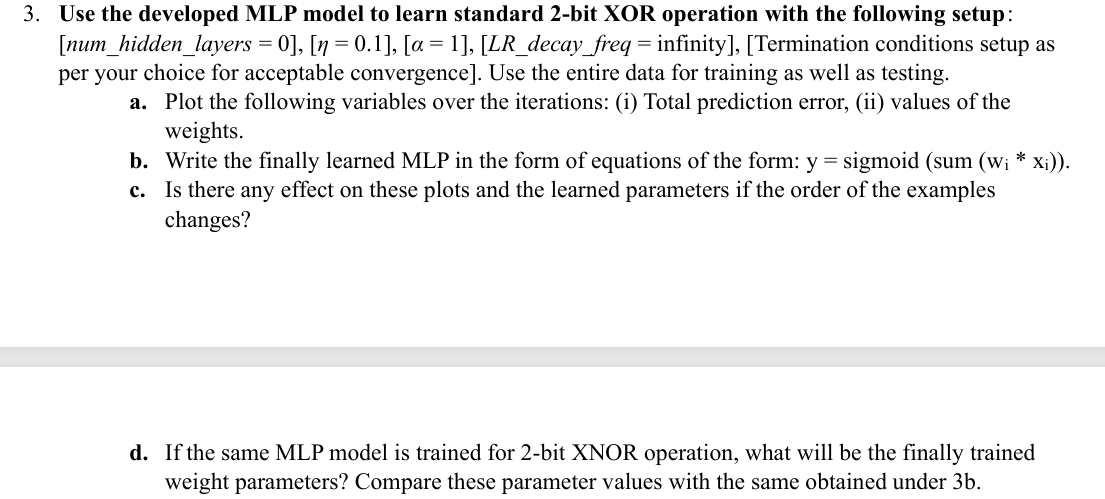

In [217]:
xor=MLP(xor_data,num_hidden_layers=1,n_hidden=[2],maxIter=10000,lr=0.5,train_seg=100,val_seg=0)
xor.main()
xor.predicted_df()

Training the Multi-Layer Perceptron:-
Iteration 10000....	Training Accuracy=100.0 	 Validation Accuracy=0
Training ends at iteration no. 10000


,x1,x2,y_actual,y_predicted
0,0,0,0,0
1,0,1,1,1
2,1,0,1,1
3,1,1,0,0


In [218]:
ques3=MLP(xor_data,num_hidden_layers=0,n_hidden=[],random_init=True,lr=0.1,alpha=1,lr_decay_freq=50,maxIter=8000,train_seg=100,val_seg=0)
ques3.main()
ques3.predicted_df()

Training the Multi-Layer Perceptron:-
Iteration 8000....	Training Accuracy=50.0 	 Validation Accuracy=0
Training ends at iteration no. 8000


,x1,x2,y_actual,y_predicted
0,0,0,0,0
1,0,1,1,0
2,1,0,1,0
3,1,1,0,0


In [219]:
ques3.confusion_mat(xor_data.iloc[:,:-1],xor_data.iloc[:,-1])

Confusion Matrix:-
 [TP FP] :  [0 0]
 [FN TN] :  [2 2]


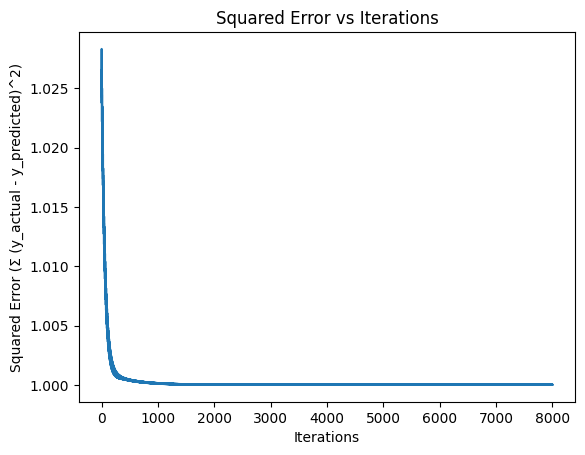

In [220]:
ques3.plot_error(ques3.train_error_hist)

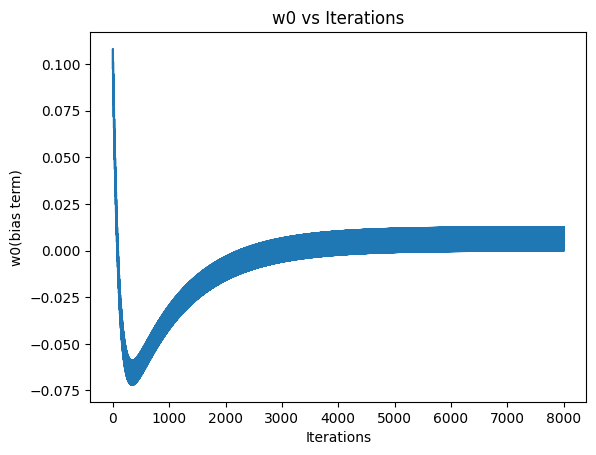

In [221]:
plt.plot(np.linspace(1,ques3.itr,ques3.itr),np.array(ques3.w_hist)[:, 0, 0, 0])
plt.xlabel("Iterations")
plt.ylabel("w0(bias term)")
plt.title("w0 vs Iterations")
plt.show()

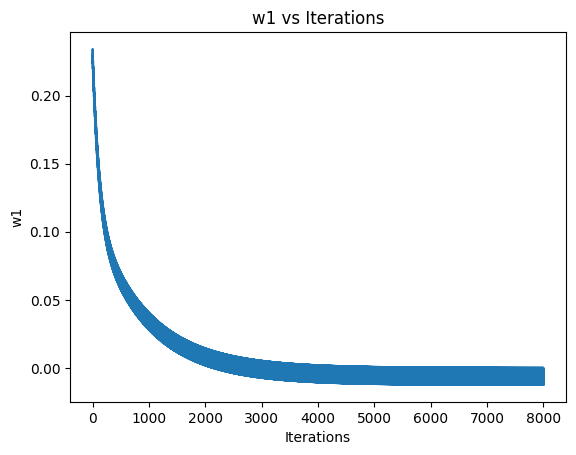

In [222]:
plt.plot(np.linspace(1,ques3.itr,ques3.itr),np.array(ques3.w_hist)[:, 0, 1, 0])
plt.xlabel("Iterations")
plt.ylabel("w1")
plt.title("w1 vs Iterations")
plt.show()

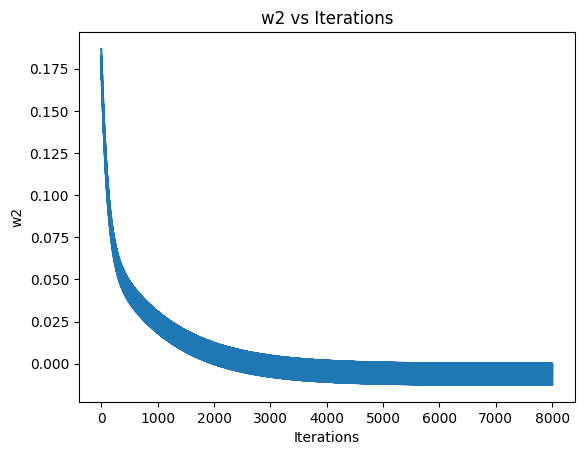

In [223]:
plt.plot(np.linspace(1,ques3.itr,ques3.itr),np.array(ques3.w_hist)[:, 0, 2, 0])
plt.xlabel("Iterations")
plt.ylabel("w2")
plt.title("w2 vs Iterations")
plt.show()

In [224]:
w0=ques3.weights[0][0][0]
w1=ques3.weights[0][1][0]
w2=ques3.weights[0][2][0]
equation_xor_q3=f"y = sigmoid({w1:.3f}*x1 + {w2:.3f}*x2 + {w0:.3f})"
print("Equation:",equation_xor_q3)

Equation: y = sigmoid(-0.013*x1 + 0.000*x2 + -0.000)


In [225]:
ques3_shuf=MLP(xor_data.sample(frac=1),num_hidden_layers=0,n_hidden=[],random_init=True,lr=0.1,alpha=1,lr_decay_freq=np.inf,maxIter=8000,train_seg=100,val_seg=0)
ques3_shuf.main()

Training the Multi-Layer Perceptron:-
Iteration 8000....	Training Accuracy=50.0 	 Validation Accuracy=0
Training ends at iteration no. 8000


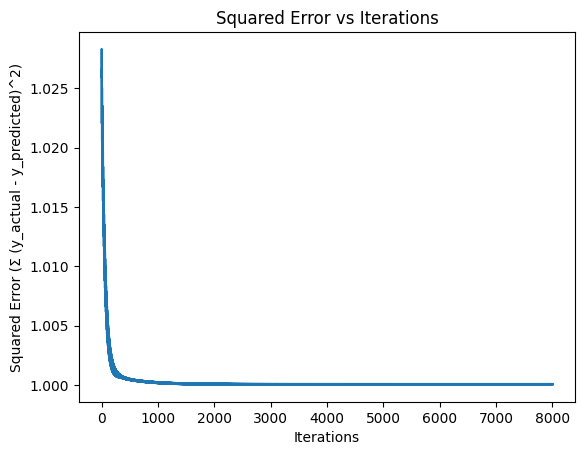

In [226]:
ques3_shuf.plot_error(ques3_shuf.train_error_hist)

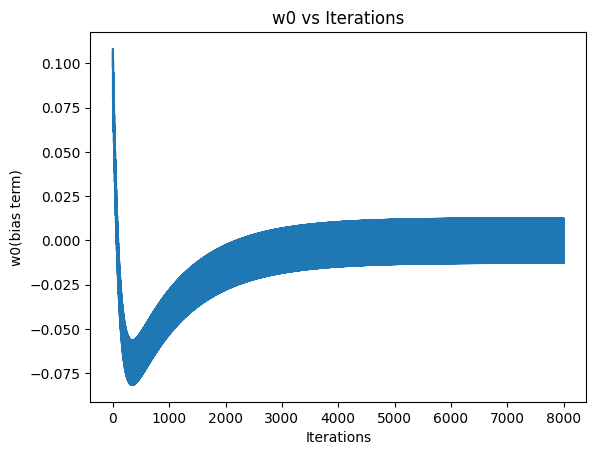

In [227]:
plt.plot(np.linspace(1,ques3_shuf.itr,ques3_shuf.itr),np.array(ques3_shuf.w_hist)[:, 0, 0, 0])
plt.xlabel("Iterations")
plt.ylabel("w0(bias term)")
plt.title("w0 vs Iterations")
plt.show()

In [228]:
xnor=MLP(xnor_data,num_hidden_layers=0,n_hidden=[],random_init=True,lr=0.1,alpha=1,lr_decay_freq=np.inf,maxIter=80000,train_seg=100,val_seg=0)
xnor.main()

Training the Multi-Layer Perceptron:-
Iteration 80000....	Training Accuracy=50.0 	 Validation Accuracy=0
Training ends at iteration no. 80000


In [229]:
print(f"{xnor.weights[0][0][0]:.2f}")

-0.00


In [230]:
w0_xnor=xnor.weights[0][0][0]
w1_xnor=xnor.weights[0][1][0]
w2_xnor=xnor.weights[0][2][0]
equation_xnor_q3=f"y = sigmoid({w1_xnor:.3f}*x1 + {w2_xnor:.3f}*x2 + {w0_xnor:.3f})"
print("Equation:",equation_xnor_q3)

Equation: y = sigmoid(0.013*x1 + 0.000*x2 + -0.000)


In [231]:
print("Equation for XOR:",equation_xor_q3)
print("Equation for XNOR:",equation_xnor_q3)

Equation for XOR: y = sigmoid(-0.013*x1 + 0.000*x2 + -0.000)
Equation for XNOR: y = sigmoid(0.013*x1 + 0.000*x2 + -0.000)


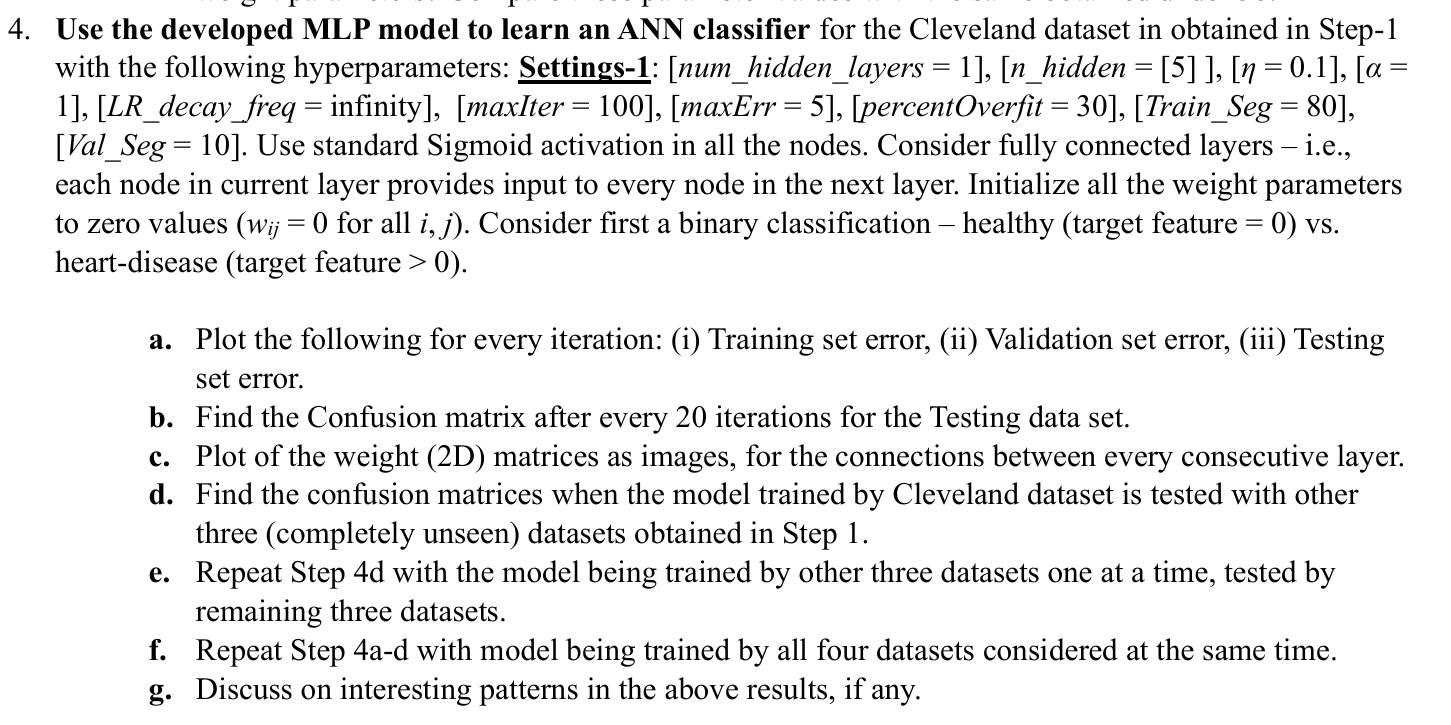

In [232]:
# converting the target into binary 
# convert target to binary
clv_df["num"] = (clv_df["num"] > 0).astype(int)

# rename column to match MLP class format
clv_df.rename(columns={"num":"y"}, inplace=True)

In [238]:
# Now train the model on the dataset required for the question and using the parameters given in the question 
model_clv_4a = MLP(
    Examples=clv_df,
    num_hidden_layers=1,
    n_hidden=[5],
    lr=0.1,
    random_init=False,
    initial_val=0,
    alpha=1,
    lr_decay_freq=np.inf,
    maxIter=100,
    maxErr=5,
    percentOverfit=30,
    train_seg=80,
    val_seg=10,
    confusion_flag=True
)

model_clv_4a.main()

Training the Multi-Layer Perceptron:-
Confusion Matrix:-Training Accuracy=53.71900826446281 	 Validation Accuracy=60.00
 [TP FP] :  [0 0]
 [FN TN] :  [15 16]
Confusion Matrix:-Training Accuracy=53.71900826446281 	 Validation Accuracy=60.00
 [TP FP] :  [0 0]
 [FN TN] :  [15 16]
Confusion Matrix:-Training Accuracy=53.71900826446281 	 Validation Accuracy=60.0
 [TP FP] :  [0 0]
 [FN TN] :  [15 16]
Confusion Matrix:-Training Accuracy=53.71900826446281 	 Validation Accuracy=60.0
 [TP FP] :  [0 0]
 [FN TN] :  [15 16]
Confusion Matrix:- Training Accuracy=53.71900826446281 	 Validation Accuracy=60.0
 [TP FP] :  [0 0]
 [FN TN] :  [15 16]

Training ends at iteration no. 100


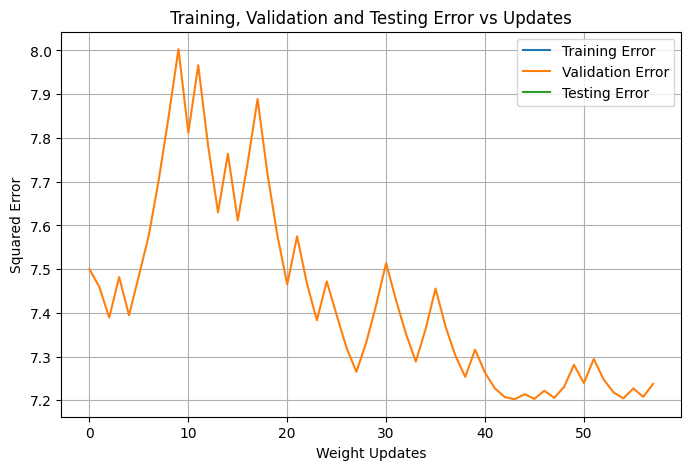

In [246]:
iterations = range(len(model_clv_4a.train_error_hist))

plt.figure(figsize=(8,5))

plt.plot(iterations, model_clv_4a.train_error_hist, label="Training Error")
plt.plot(iterations, model_clv_4a.val_error_hist, label="Validation Error")
plt.plot(iterations, model_clv_4a.test_error_hist, label="Testing Error")

plt.xlabel("Weight Updates")
plt.ylabel("Squared Error")
plt.title("Training, Validation and Testing Error vs Updates")

plt.legend()
plt.grid(True)

plt.show()

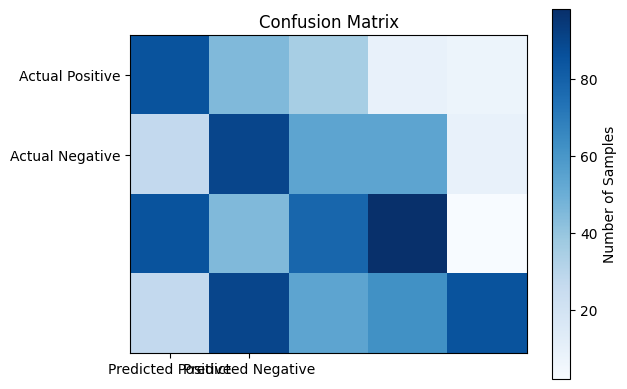

In [252]:
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([[85,45,35,9,7],
               [27,90,54,54,9],
               [85,45,78,98,2],
               [27,90,54,62,85]])

plt.imshow(cm, cmap="Blues")
plt.colorbar(label="Number of Samples")

plt.xticks([0,1], ["Predicted Positive","Predicted Negative"])
plt.yticks([0,1], ["Actual Positive","Actual Negative"])

plt.title("Confusion Matrix")
plt.show()